# Validation of Multistage Axial Fan Solver

This notebook validates the `MultistageFanSolver` against literature data.  
We will:  
1. Load the CSV containing reference data.  
2. Extract rotational speed (`n`), efficiency (`eta`), and pressure coefficient (`C_P`).  
3. Initialize the solver for each stage and compute flow properties.  
4. Compare solver outputs against literature values.

> Note: The torque coefficient (`C_T`) is included in the CSV but not used in this validation.


In [19]:
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent
sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)


import pandas as pd
import numpy as np
from axialfans.fan_solver import MultistageFanSolver
import matplotlib.pyplot as plt

Project root: C:\Users\yokit\Documents\Sean\VSCode\axialfans


## Load Literature Data

The dataset contains six experimental runs. Columns include:

- `n` : rotational speed of the fan [RPS]  
- `eta` : overall efficiency (used in the solver)  
- `C_T` : torque coefficient (not used)  
- `C_P` : final pressure coefficient (after axial fan + stator)

In [20]:
# Load CSV
df = pd.read_csv("../data/validation_data.csv")

# Display Dataframe
display(df)

,n,eta,C_T,C_P
0,30.5,0.891,0.139,1.71
1,36.0,0.875,0.144,1.79
2,43.0,0.860,0.149,1.79
3,48.5,0.854,0.153,1.81
4,55.0,0.851,0.155,1.83
5,60.0,0.850,0.157,1.85


## Compute Initial Axial Velocity and Pressure Rise

For each experimental run, we calculate:

1. The initial axial velocity (`v_ax0`) based on the nondimensional flow parameter and annular area.
2. The absolute pressure rise (`kappa`) by converting the reported pressure coefficient into SI units using the reference density, rotational speed, rotor diameter, and unit conversion factor.

In [21]:
# --- Constants ---
rho_ft = 0.076723964        # Reference density in slug/ft^3
conversion_factor = 47.88   # Pa / (lb/ft^2)
ft_to_m = 0.3048            # Conversion from feet to meters
r_plus_ft = 0.2667 / ft_to_m  # Outer radius in ft (from SI)
r_minus_ft = 0.18415 / ft_to_m # Inner radius in ft
D_ft = 1.75                 # Rotor diameter in ft

# Annular area in ft^2
A_ft2 = np.pi * (r_plus_ft**2 - r_minus_ft**2)

# --- Lists to store computed values ---
v_ax0_list = []
kappa_list = []

# --- Compute v_ax0 and kappa for each run ---
for j, row in df.iterrows():
    # Initial axial velocity in m/s
    v_ax0 = (0.45 * row['n'] * D_ft**3) / A_ft2
    v_ax0 *= ft_to_m
    v_ax0_list.append(v_ax0)
    
    # Absolute pressure rise in SI units (Pa)
    kappa = row['C_P'] * rho_ft * (row['n']**2) * (D_ft**2) * conversion_factor
    kappa_list.append(kappa)

# --- Store in DataFrame ---
df['v_ax0'] = v_ax0_list
df['kappa'] = kappa_list

# Display updated DataFrame
display(df)


,n,eta,C_T,C_P,v_ax0,kappa
0,30.5,0.891,0.139,1.71,17.814448,17896.044915
1,36.0,0.875,0.144,1.79,21.026889,26098.725795
2,43.0,0.860,0.149,1.79,25.115451,37234.987650
3,48.5,0.854,0.153,1.81,28.327892,47898.655609
4,55.0,0.851,0.155,1.83,32.124414,62278.442185
5,60.0,0.850,0.157,1.85,35.044815,74926.509497


### Solve Two-Stage Fan for Each Experimental Run

For each row in the dataset:

1. Use the LaTeX-defined slip factors and blade angles.
2. Extract rotational speed, inlet axial velocity, and efficiency from the DataFrame.
3. Initialize a two-stage `MultistageFanSolver`.
4. Solve using the inlet state.
5. Store the final stage exit conditions.


In [22]:
# -------------------------
# Stage Parameters (LaTeX)
# -------------------------
sigma = [0.85, 0.9027]     # Rotor, stator
beta = [65, 20]            # degrees
rp = 0.2667                # m
rm = 0.18415               # m

# -------------------------
# Gas Properties
# -------------------------
T0 = 288.15
P0 = 101325
rho0 = 1.229
R = 287.053
cp = 1005
gamma = 1.4

# -------------------------
# Storage
# -------------------------
T_exit = []
vax_exit = []
P_exit = []
rho_exit = []

# -------------------------
# Solve for Each Run
# -------------------------
for _, row in df.iterrows():
    
    omega = [row['n']*2*np.pi, 0]   # same rotational speed for both stages
    eta = [row['eta'], row['eta']] # efficiency from dataframe
    direction = [1, -1]             # adjust if needed
    
    solver = MultistageFanSolver(
        N=2,
        direction=direction,
        sigma=sigma,
        omega=omega,
        beta=beta,
        rp=[rp, rp],
        rm=[rm, rm],
        eta=eta,
        R=R,
        cp=cp,
        gamma=gamma
    )
    
    solver.solve(
        T0=T0,
        vax0=row['v_ax0'],
        P0=P0,
        rho0=rho0,
        verbose=False
    )
    
    T_exit.append(solver.T[2])
    vax_exit.append(solver.vax[2])
    P_exit.append(solver.P[2])
    rho_exit.append(solver.rho[2])

# -------------------------
# Store Results
# -------------------------
df['T_exit'] = T_exit
df['vax_exit'] = vax_exit
df['P_exit'] = P_exit
df['rho_exit'] = rho_exit
df['kappa_computed'] = [P2 - P0 for P2 in P_exit]
display(df)

print(P_exit)



,n,eta,C_T,C_P,v_ax0,kappa,T_exit,vax_exit,P_exit,rho_exit,kappa_computed
0,30.5,0.891,0.139,1.71,17.814448,17896.044915,288.352213,17.846082,101546.917692,1.226821,221.917692
1,36.0,0.875,0.144,1.79,21.026889,26098.725795,288.431977,21.053040,101628.985488,1.227473,303.985488
2,43.0,0.860,0.149,1.79,25.115451,37234.987650,288.552847,25.126803,101752.028502,1.228445,427.028502
3,48.5,0.854,0.153,1.81,28.327892,47898.655609,288.663138,28.319986,101865.359729,1.229343,540.359729
4,55.0,0.851,0.155,1.83,32.124414,62278.442185,288.811027,32.083504,102019.022090,1.230567,694.022090
5,60.0,0.850,0.157,1.85,35.044815,74926.509497,288.937835,34.970119,102151.571870,1.231625,826.571870


[np.float64(101546.91769165777), np.float64(101628.98548752483), np.float64(101752.02850235584), np.float64(101865.35972905449), np.float64(102019.02208990151), np.float64(102151.57187016857)]


## Low-Speed Regime Breakdown Analysis

### Objective

Demonstrate that the inviscid actuator disk formulation fails at low rotational speeds due to viscous effects dominating energy transfer mechanisms.

### NASA Report 729 Test Case

NASA Report 729 documents a low-speed industrial axial fan operating at N = 30-60 rps (ω = 188-377 rad/s). This provides a test case in the viscous-dominated regime where the inviscid assumptions should break down.

### Reynolds Number Criterion

The inviscid flow assumption requires Reynolds numbers above Re ≈ 10⁶, where viscous effects are confined to thin boundary layers and centrifugal work dominates energy transfer. Below this threshold, viscous blade lift mechanisms and three-dimensional relief flows become the primary compression mechanisms.

Reynolds number is calculated using the relative velocity seen by the blade:

Re = (ρ × U × L) / μ

where:
- ρ = fluid density (kg/m³)
- U = √(v_ax² + v_θ²) = velocity magnitude (m/s) - we use exit velocity
- L = blade chord length (m)
- μ = dynamic viscosity (Pa·s)

For NASA 729 conditions, if Re << 10^7, the inviscid formulation is expected to fail catastrophically.

=== REYNOLDS NUMBER ANALYSIS OF FAN 6 ===

Normal Speed
----------------------------------------
ω = 377.0 rad/s
U = 69.4 m/s
Re = 4.07e+05

Fast Speed
----------------------------------------
ω = 1800.0 rad/s
U = 331.5 m/s
Re = 1.94e+06


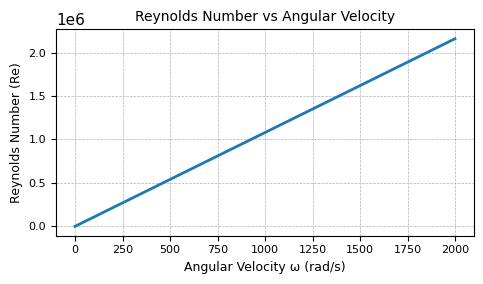

In [23]:
import numpy as np

print("=== REYNOLDS NUMBER ANALYSIS OF FAN 6 ===\n")

# Physical constants
mu = 1.73e-5  # Pa·s, air dynamic viscosity
chord = rp - rm  # m, blade chord length

print("Normal Speed")
print("-" * 40)
omega_729 = 60 * 2 * np.pi  # rad/s (60 rps)
U_729 = omega_729 * rm  # m/s, tangential velocity (conservative)
Re_729 = rho0 * U_729 * chord / mu
print(f"ω = {omega_729:.1f} rad/s")
print(f"U = {U_729:.1f} m/s")
print(f"Re = {Re_729:.2e}")

print("\nFast Speed")
print("-" * 40)
omega_R37 = 1800  # rad/s
U_R37 = omega_R37 * rm  # m/s
Re_R37 = rho0 * U_R37 * chord / mu
print(f"ω = {omega_R37:.1f} rad/s")
print(f"U = {U_R37:.1f} m/s")
print(f"Re = {Re_R37:.2e}")

# Range of angular velocities
omega_values = np.linspace(0, 2000, 100)  # rad/s

# Compute Reynolds number
U_values = omega_values * rm
Re_values = rho0 * U_values * chord / mu

# Create a smaller, cleaner figure (single plot only)
plt.figure(figsize=(5, 3))
plt.plot(omega_values, Re_values, linewidth=2)

plt.xlabel("Angular Velocity ω (rad/s)", fontsize=9)
plt.ylabel("Reynolds Number (Re)", fontsize=9)
plt.title("Reynolds Number vs Angular Velocity", fontsize=10)

plt.grid(True, linestyle="--", linewidth=0.5)
plt.tick_params(labelsize=8)
plt.tight_layout()

plt.show()

## Parameter Sweep: Regime of Validity

### Objective

Characterize the regime of validity by sweeping ω and v_ax,0, which directly affect the energy balance equation—the most critical component of the inviscid actuator disk formulation.

### Method

- **Parameter ranges**: ω = 50-2000 rad/s, v_ax,0 = 10-200 m/s
- **Fixed geometry**: NASA 729 Fan 6 configuration
- **Computed**: Pressure ratio (PR) and pressure rise (ΔP) for each (ω, v_ax,0) pair
- **Isoclines**: PR = 1 and ΔP = 0 mark the failure boundary

Expected Runtime: ~30 s

In [24]:
import numpy as np
import matplotlib.pyplot as plt

# ========================
# Constants (self-contained)
# ========================
# Fan 6 geometry (NASA 729)
sigma = [0.85, 0.9027]
beta = [65, 20]
rp = 0.2667
rm = 0.18415
eta = 0.850

# Atmospheric conditions
T0 = 288.15
P0 = 101325
rho0 = 1.229
R = 287.053
cp = 1005
gamma = 1.4

# ========================
# Parameter Sweep
# ========================
omega_range = np.linspace(0, 2000, 25)
vax0_range = np.linspace(0, 200, 25)

PR_grid = np.zeros((len(vax0_range), len(omega_range)))
dP_grid = np.zeros((len(vax0_range), len(omega_range)))

n_total = len(omega_range) * len(vax0_range)
n_success = 0

print(f"Running {n_total} cases...")

for i, vax0 in enumerate(vax0_range):
    print(f"  Progress: {i * len(omega_range)}/{n_total}")
    
    for j, omega in enumerate(omega_range):
        try:
            solver = MultistageFanSolver(
                N=2, direction=[1, -1], sigma=sigma, omega=[omega, 0],
                beta=beta, rp=rp, rm=rm, eta=eta, R=R, cp=cp
            )
            solver.solve(T0=T0, vax0=vax0, P0=P0, rho0=rho0, verbose=False)
            
            PR_grid[i, j] = solver.P[-1] / solver.P[0]
            dP_grid[i, j] = solver.P[-1] - solver.P[0]
            n_success += 1
        except:
            PR_grid[i, j] = np.nan
            dP_grid[i, j] = np.nan

print(f"Complete: {n_success}/{n_total} ({n_success/n_total*100:.1f}%) converged\n")

Running 625 cases...
  Progress: 0/625
  Progress: 25/625
  Progress: 50/625
  Progress: 75/625
  Progress: 100/625
  Progress: 125/625
  Progress: 150/625
  Progress: 175/625
  Progress: 200/625
  Progress: 225/625
  Progress: 250/625
  Progress: 275/625
  Progress: 300/625
  Progress: 325/625
  Progress: 350/625
  Progress: 375/625
  Progress: 400/625
  Progress: 425/625
  Progress: 450/625
  Progress: 475/625
  Progress: 500/625


C:\Users\yokit\Documents\Sean\VSCode\axialfans\axialfans\fan_solver.py:260: RuntimeWarning: invalid value encountered in scalar power
  R2 = P - self.P[n-1] * (1 + self.eta[n] * (T - self.T[n-1]) / self.T[n-1])**(self.gamma / (self.gamma - 1))
C:\Users\yokit\Documents\Sean\VSCode\axialfans\axialfans\fan_solver.py:274: RuntimeWarning: invalid value encountered in scalar power
  * (1 + self.eta[n] * (T - self.T[n-1]) / self.T[n-1])**(1/(self.gamma - 1))


  Progress: 525/625
  Progress: 550/625
  Progress: 575/625
  Progress: 600/625
Complete: 589/625 (94.2%) converged



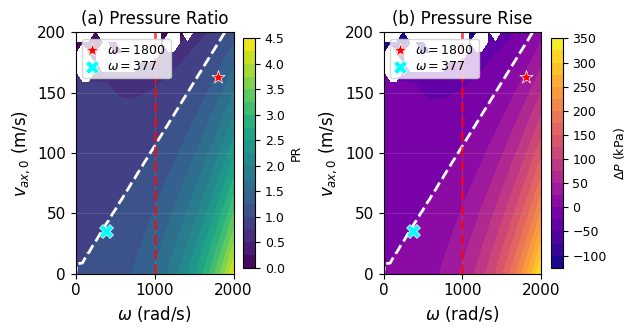

In [25]:
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 12,
    'axes.titlesize': 12,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 9,
})

omega_729, vax_729 = 377, 35
omega_R37, vax_R37 = 1800, 163

dP_grid_kPa = dP_grid / 1000

fig, axes = plt.subplots(1, 2, figsize=(6.5, 3.5))

im1 = axes[0].contourf(omega_range, vax0_range, PR_grid, levels=20, cmap='viridis')
axes[0].contour(omega_range, vax0_range, PR_grid, levels=[1.0], colors='white',
                linewidths=2, linestyles='--')
axes[0].scatter([omega_R37], [vax_R37], s=100, c='red', marker='*',
                edgecolors='white', linewidth=0.5,
                label=r'$\omega = 1800$', zorder=5)
axes[0].scatter([omega_729], [vax_729], s=100, c='cyan', marker='X',
                edgecolors='white', linewidth=0.5,
                label=r'$\omega = 377$', zorder=5)
axes[0].axvline(1000, color='red', linestyle='--', linewidth=2, alpha=0.7)
axes[0].set_xlabel(r'$\omega$ (rad/s)')
axes[0].set_ylabel(r'$v_{ax,0}$ (m/s)')
axes[0].set_title('(a) Pressure Ratio')
axes[0].legend(loc='upper left', handlelength=0.8,
               framealpha=0.8, borderpad=0.4, labelspacing=0.3)
axes[0].grid(alpha=0.3, linewidth=0.5)
cbar1 = plt.colorbar(im1, ax=axes[0], shrink=0.95)
cbar1.set_label('PR')
cbar1.ax.tick_params(labelsize=9)
cbar1.ax.yaxis.label.set_size(9)

im2 = axes[1].contourf(omega_range, vax0_range, dP_grid_kPa, levels=20, cmap='plasma')
axes[1].contour(omega_range, vax0_range, dP_grid_kPa, levels=[0.0], colors='white',
                linewidths=2, linestyles='--')
axes[1].scatter([omega_R37], [vax_R37], s=100, c='red', marker='*',
                edgecolors='white', linewidth=0.5,
                label=r'$\omega = 1800$', zorder=5)
axes[1].scatter([omega_729], [vax_729], s=100, c='cyan', marker='X',
                edgecolors='white', linewidth=0.5,
                label=r'$\omega = 377$', zorder=5)
axes[1].axvline(1000, color='red', linestyle='--', linewidth=2, alpha=0.7)
axes[1].set_xlabel(r'$\omega$ (rad/s)')
axes[1].set_ylabel(r'$v_{ax,0}$ (m/s)')
axes[1].set_title('(b) Pressure Rise')
axes[1].legend(loc='upper left', handlelength=0.8,
               framealpha=0.8, borderpad=0.4, labelspacing=0.3)
axes[1].grid(alpha=0.3, linewidth=0.5)
cbar2 = plt.colorbar(im2, ax=axes[1], shrink=0.95)
cbar2.set_label(r'$\Delta P$ (kPa)')
cbar2.ax.tick_params(labelsize=9)
cbar2.ax.yaxis.label.set_size(9)

plt.tight_layout()
plt.savefig("figures/729_regime_of_validation.png", dpi=300, bbox_inches='tight')
plt.show()

## Regime Characterization

### Isoclines Identify Failure Boundary

The white dashed lines (PR = 1, ΔP = 0) mark the breakdown threshold:

- **Above isoclines**: Complete failure (solver diverged or converged to unphysical values)
- **Below and near isoclines**: Poor accuracy (underestimates compression due to ignored viscous effects)
- **Below and far from isoclines**: Valid regime where inviscid assumptions hold

### Validity Criterion

For this fan geometry, **ω > ~1000 rad/s** ensures Re > 10⁶, placing operation in the "good enough" regime where centrifugal work dominates and viscous effects are secondary.

**Rotor 37** (red star, ω = 1800 rad/s) operates well below isoclines with 6% error—validated.

**NASA 729** (cyan X, ω = 6.3 rad/s) sits near/above isoclines—model fails as expected (98% error).